In [1]:
import numba
import numpy as np
import pygmt as pygmt
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import scipy as scipy
import V2RhoT_gibbs_lib as V2RhoT_gibbs_lib
#import V2RhoT_gibbs_lib_prev as V2RhoT_gibbs_lib_prev


In [2]:
long_min=65;long_max=115
lat_min=5;lat_max=45
depth_min=0e3
depth_max=350
region=[long_min,long_max,lat_min,lat_max]
TABEL_DMM =np.loadtxt('./../databases/DMM_HP')
TABEL_DMM_corr= V2RhoT_gibbs_lib.mantle_melt_atten_correction_Behn2009(TABEL_DMM,grain_size=10,oscillation=75,COH=100)
#TABEL_DMM_corr_prev= V2RhoT_gibbs_lib_prev.mantle_melt_atten_correction_Behn2009(TABEL_DMM,grain_size=10,oscillation=75,COH=100)

In [3]:
Tomo = pd.read_csv('/home/ajay/projects/RESOURCES/data/Seismic_tomo_data/CAM2024/CAM2023.emc/V2RhoT_gibbs/CAM2023_vsvabs.dat',sep=r"\s+")
#Tomo = pd.read_csv('/./input/Raw_Tomo_data/FWEA23.r0.0_to_convert_0-400km.txt',sep=r"\s+")
#Tomo = pd.read_csv('./input/Raw_Tomo_data/IK2024_Vsv.dat',sep=r"\s+")
#Tomo = pd.read_csv('./input/Raw_Tomo_data/ASIA2024_to_convert.txt',sep=r"\s+")
# Rename specific indices (assuming #Longitude is 0, Latitude is 1, Depth is 2, Vs is 3)
cols = Tomo.columns.to_list()
cols[0] = '#long'
cols[1] = 'lat'
cols[2] = 'depth(km)'
cols[3] = 'Vs(km/s)'
Tomo.columns = cols
# Now filter directly using index or updated names
#Tomo_use_region = Tomo[
#    (Tomo.iloc[:, 0] >= region[0]) & (Tomo.iloc[:, 0] <= region[1]) & 
#    (Tomo.iloc[:, 1] >= region[2]) & (Tomo.iloc[:, 1] <= region[3])
#].copy()

# Now filter directly using index or updated names
#Tomo_use_region = Tomo[
#    (Tomo.iloc[:, 2] >= 40) & (Tomo.iloc[:, 2] <= 200)].copy()
#print(Tomo_use_region.head())
#print(Tomo_use_region["depth(km)"].max())

In [4]:
Tomo_use_region=Tomo.copy()

In [5]:
Tomo_use_region['depth(km)'].unique()

array([ 40,  50,  70,  90, 100, 125, 150, 175, 200, 210, 230, 250, 275,
       300])

In [15]:
Tomo_use=Tomo_use_region[ (Tomo_use_region['depth(km)'] >= 200) & (Tomo_use_region['depth(km)'] <= 200)].copy()
tomo_converted=V2RhoT_gibbs_lib.vel_vs_to_temp_prop_out(Tomo_use['depth(km)'].to_numpy(),Tomo_use['Vs(km/s)'].to_numpy(),TABEL_DMM_corr)
Tomo_use=tomo_converted.copy()

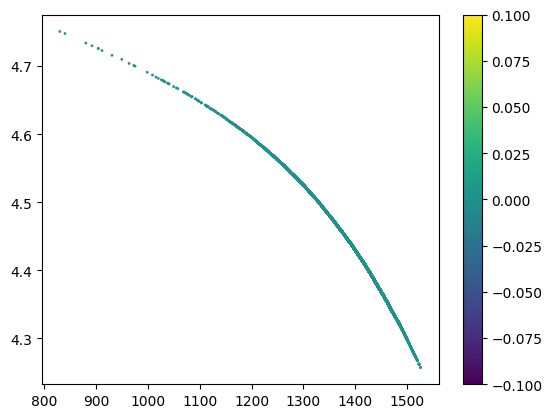

In [16]:
data=Tomo_use
plt.scatter(x=data[:,2],y=data[:,-3],s=1,c=data[:,-1])
plt.colorbar()

In [ ]:
Tomo_use_prev=Tomo_use_region[ (Tomo_use_region['depth(km)'] >= depth_min) & (Tomo_use_region['depth(km)'] <= depth_max)].copy()
tomo_converted=V2RhoT_gibbs_lib_prev.vel_vs_to_temp_prop_out(Tomo_use_prev['depth(km)'].to_numpy(),Tomo_use_prev['Vs(km/s)'].to_numpy(),TABEL_DMM_corr_prev)
Tomo_use_prev['Density(kg/m3)']=tomo_converted[:,3]
Tomo_use_prev['T(oC)']=tomo_converted[:,2]
Tomo_use_prev['depth(km)']=Tomo_use_prev['depth(km)']*1e3
Tomo_use_prev['diff_vs']=tomo_converted[:,-2]
Tomo_use_prev['melft_f']=tomo_converted[:,-1]


In [6]:
print(Tomo_use.head())

        #long  lat  depth(km)  Vs(km/s)  Density(kg/m3)        T(oC)
247455   65.0  5.0    20000.0     3.824     3220.318905  1209.397465
247456   65.0  5.0    40000.0     4.079     3242.509756  1284.537654
247457   65.0  5.0    60000.0     4.328     3291.444225  1203.354945
247458   65.0  5.0    80000.0     4.471     3333.078262  1112.843892
247459   65.0  5.0   100000.0     4.417     3342.806066  1220.453336


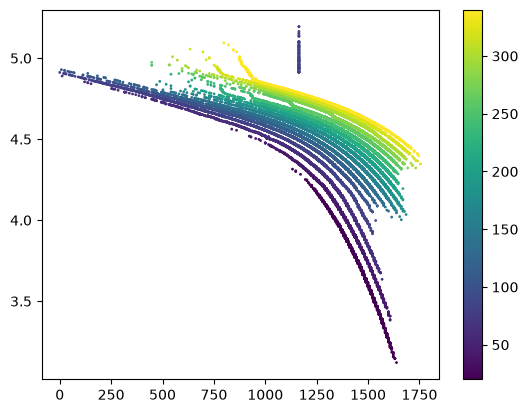

In [14]:
plt.scatter(x=Tomo_use_prev['T(oC)'],y=Tomo_use_prev['Vs(km/s)'],s=1,c=Tomo_use_prev['depth(km)']*1e-3)
plt.colorbar()


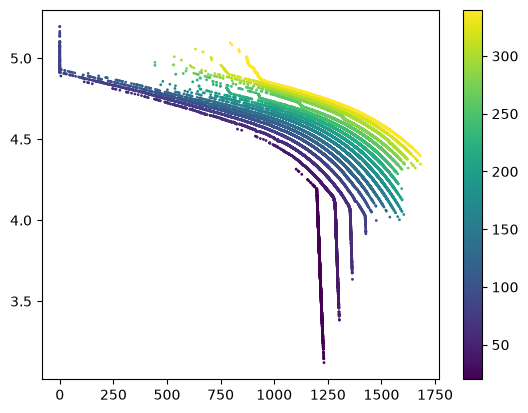

In [15]:
plt.scatter(x=Tomo_use['T(oC)'],y=Tomo_use['Vs(km/s)'],s=1,c=Tomo_use['']*1e-3)
plt.colorbar()

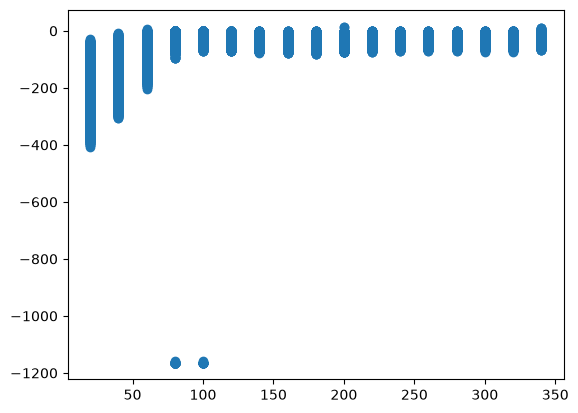

In [8]:
plt.plot(Tomo_use_prev['depth(km)']*1e-3,Tomo_use['T(oC)']-Tomo_use_prev['T(oC)'],'o')


In [9]:
Tomo_use['depth(km)'].unique()

array([ 20000.,  40000.,  60000.,  80000., 100000., 120000., 140000.,
       160000., 180000., 200000., 220000., 240000., 260000., 280000.,
       300000., 320000., 340000.])

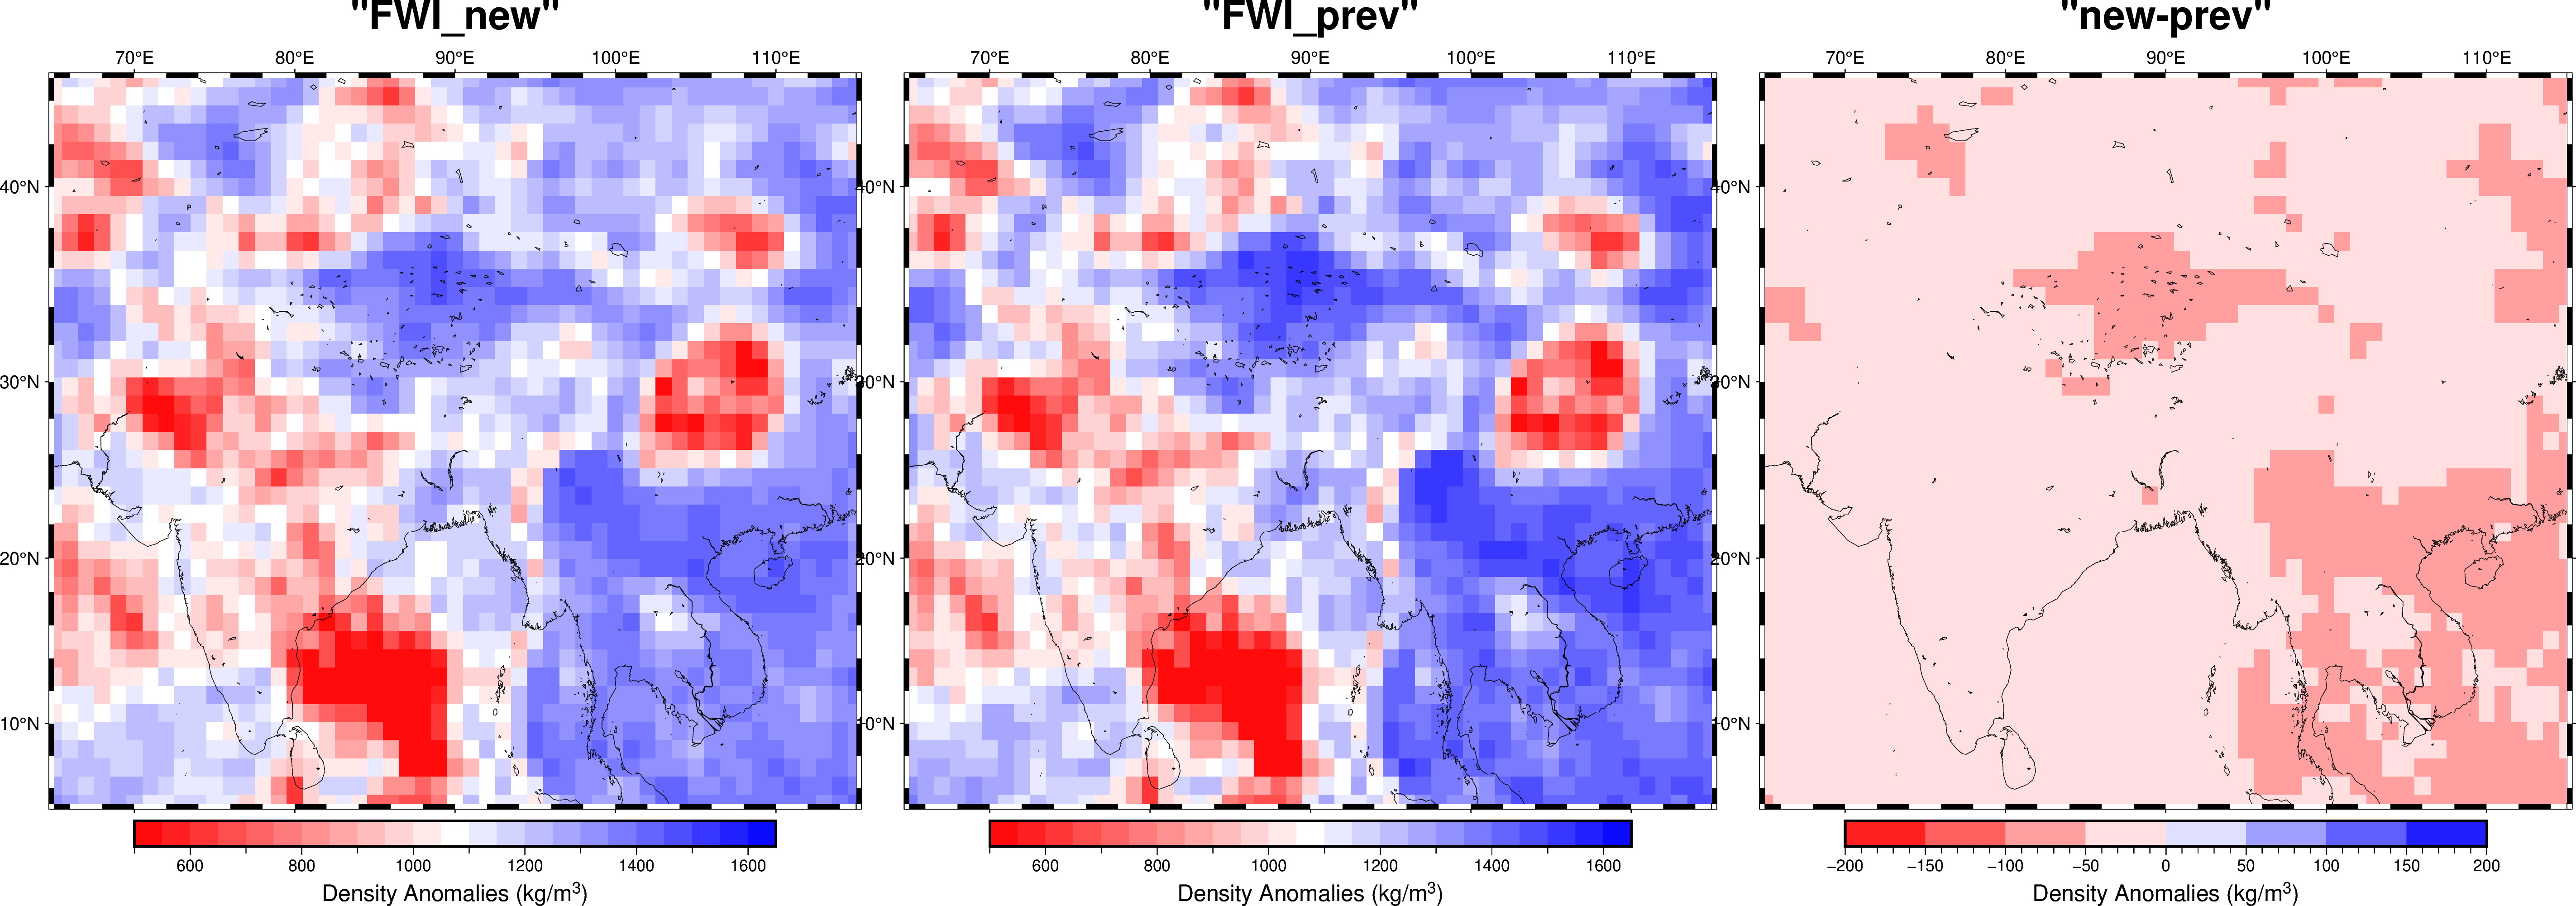

In [32]:
Title = "Results_"

depth=120000
tomo_slice=Tomo_use[ Tomo_use['depth(km)'] == depth]# & (Tomo_use_region['depth(km)'] <= depth_max)].copy()
tomo_slice_prev=Tomo_use_prev[ Tomo_use_prev['depth(km)'] == depth]# & (Tomo_use_region['depth(km)'] <= depth_max)].copy()

grd_plot = pygmt.xyz2grd(x=tomo_slice['#long'],y=tomo_slice['lat'],z=tomo_slice['T(oC)'],region=region,spacing=(1, 1))
grd_plot_prev = pygmt.xyz2grd(x=tomo_slice['#long'],y=tomo_slice['lat'],z=tomo_slice_prev['T(oC)'],region=region,spacing=(1, 1))

grd_plot_diff = pygmt.xyz2grd(x=tomo_slice['#long'],y=tomo_slice['lat'],z=tomo_slice['T(oC)']-tomo_slice_prev['T(oC)'],region=region,spacing=(1, 1))
title_str3='FWI_new'
frame = [f'WsNe+t"{title_str3}"', "af"]
region = region
size = 15
xshift=2
projection = "M"+str(size)+"c"
fig = pygmt.Figure()
fig.basemap(projection=projection, frame=frame, region=region)
cpt_density = pygmt.makecpt(cmap="polar",reverse=True,series=[500, 1650, 50],background="o",continuous=False,)
fig.grdimage(grid=grd_plot,projection=projection,region=region,cmap=cpt_density,)
fig.coast(region=region,projection=projection,shorelines="0.2p,black",resolution="l",)
name_prior = "Density Anomalies (kg/m@+3@+)"
fig.colorbar(cmap=cpt_density, box=False, frame=["a200f100", "x+l" + name_prior])

title_str3='FWI_prev'
frame = [f'WsNe+t"{title_str3}"', "af"]
fig.shift_origin(xshift=16)
fig.basemap(projection=projection, frame=frame, region=region)
cpt_density = pygmt.makecpt(cmap="polar",reverse=True,series=[500, 1650, 50],background="o",continuous=False,)

fig.grdimage(grid=grd_plot_prev,projection=projection,region=region,cmap=cpt_density,)
fig.coast(region=region,projection=projection,shorelines="0.2p,black",resolution="l",)
name_prior = "Density Anomalies (kg/m@+3@+)"
fig.colorbar(cmap=cpt_density, box=False, frame=["a200f100", "x+l" + name_prior])


title_str3='new-prev'
frame = [f'WsNe+t"{title_str3}"', "af"]
fig.shift_origin(xshift=16)
fig.basemap(projection=projection, frame=frame, region=region)
cpt_density = pygmt.makecpt(cmap="polar",reverse=True,series=[-200, 200, 50],background="o",continuous=False,)
fig.grdimage(grid=grd_plot_diff,projection=projection,region=region,cmap=cpt_density,)
fig.coast(region=region,projection=projection,shorelines="0.2p,black",resolution="l",)
name_prior = "Density Anomalies (kg/m@+3@+)"
fig.colorbar(cmap=cpt_density, box=False, frame=["a50f10", "x+l" + name_prior])
fig.show()
fig.savefig('./t_'+str(depth)+'.png')

In [5]:
# SAVING
#Tomo_use.to_csv('./input/tomo_converted/Tomo_use_FWI_SinoScope_DMM_HP_converted.csv')
#Tomo_use.to_csv('./input/tomo_converted/Tomo_use_FWEA23_DMM_HP_converted.csv')
#Tomo_use.to_csv('./input/tomo_converted/scattered_Tomo_use_IK2024_DMM_HP_converted.csv')
#Tomo_use.to_csv('./input/tomo_converted/Tomo_use_ASIA_DMM_HP_converted.csv')
